# Label Distribution

In [12]:
from pathlib import Path

# === Update these to match your dataset ===
INPUT_CSV = Path("/home/ubuntu/TW_MultiLabel_SMP/datasets/2000_Posts_Annotations - Combined_Dataset.csv")
OUTPUT_DIR = Path("/home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/analysis_op")

# Your column names in the CSV
TITLE_COL   = "title"         # title column
BODY_COL = "body"            # body column
LABELS_COL = "Tags"       # comma-separated labels

# Canonical label set (use your exact labels)
CANON_LABELS = [
    "Abuse", "Aggression", "Sexual", "Medical", "Mental Health",
    "Discrimination", "Pregnancy","Not Applicable"
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("✅ Config set. Output dir:", OUTPUT_DIR.resolve())


✅ Config set. Output dir: /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/analysis_op


In [13]:
import pandas as pd

df = pd.read_csv(INPUT_CSV)
print("Loaded dataframe shape:", df.shape)

# Sanity Check 
missing = [c for c in [TITLE_COL, BODY_COL, LABELS_COL] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Create a unified text column for downstream analyses
def _safe_str(x):
    return "" if pd.isna(x) else str(x)

df["text"] = df.apply(lambda r: (_safe_str(r[TITLE_COL]).strip() + " " + _safe_str(r[BODY_COL]).strip()).strip(), axis=1)

# Quick peek
display(df[[TITLE_COL, BODY_COL, "text", LABELS_COL]].head(3))
print("Nulls per column:\n", df[[TITLE_COL, BODY_COL, "text", LABELS_COL]].isna().sum())


Loaded dataframe shape: (2000, 7)


,title,body,text,Tags
0,Complications after abortion?,"Hi everyone, Ive read that abortions don’t cau...","Complications after abortion? Hi everyone, Ive...","Medical, Pregnancy, Mental Health"
1,Second MA abortion today and I'm absolutely te...,I'm having my second MA abortion today and I'm...,Second MA abortion today and I'm absolutely te...,"Medical, Pregnancy, Mental Health"
2,Help needed/ live in Texas where abortion in b...,Anyone know of a legit site to support women i...,Help needed/ live in Texas where abortion in b...,Medical


Nulls per column:
 title    0
body     0
text     0
Tags     2
dtype: int64


In [14]:
from collections import Counter

def parse_label_list(x):
    if pd.isna(x) or str(x).strip() == "":
        return []
    # Split by comma; trim spaces
    return [t.strip() for t in str(x).split(",") if t.strip()]

df["labels_list"] = df[LABELS_COL].apply(parse_label_list)

# warn if any labels fall outside the canonical set
oov_counts = Counter(l for lst in df["labels_list"] for l in lst if l not in CANON_LABELS)
if oov_counts:
    print("⚠️ Found labels not in CANON_LABELS:", dict(oov_counts))
else:
    print("✅ All labels conform to CANON_LABELS")

display(df[[LABELS_COL, "labels_list"]].head(5))

✅ All labels conform to CANON_LABELS


,Tags,labels_list
0,"Medical, Pregnancy, Mental Health","[Medical, Pregnancy, Mental Health]"
1,"Medical, Pregnancy, Mental Health","[Medical, Pregnancy, Mental Health]"
2,Medical,[Medical]
3,Medical,[Medical]
4,"Pregnancy, Mental Health","[Pregnancy, Mental Health]"


In [15]:
def to_multi_hot(label_list, all_labels):
    return {f"y__{lab}": int(lab in label_list) for lab in all_labels}

mh = df["labels_list"].apply(lambda lst: to_multi_hot(lst, CANON_LABELS)).apply(pd.Series)

# ensure columns exist even if some labels never appear
for lab in CANON_LABELS:
    col = f"y__{lab}"
    if col not in mh.columns:
        mh[col] = 0

df = pd.concat([df, mh], axis=1)
df["has_any_label"] = df["labels_list"].apply(lambda lst: len(lst) > 0)

print("✅ Multi-hot columns added:", [c for c in df.columns if c.startswith("y__")][:5], "...")
display(df[[TITLE_COL, "text", "labels_list"] + [c for c in df.columns if c.startswith("y__")]].head(3))

✅ Multi-hot columns added: ['y__Abuse', 'y__Aggression', 'y__Sexual', 'y__Medical', 'y__Mental Health'] ...


,title,text,labels_list,y__Abuse,y__Aggression,y__Sexual,y__Medical,y__Mental Health,y__Discrimination,y__Pregnancy,y__Not Applicable
0,Complications after abortion?,"Complications after abortion? Hi everyone, Ive...","[Medical, Pregnancy, Mental Health]",0,0,0,1,1,0,1,0
1,Second MA abortion today and I'm absolutely te...,Second MA abortion today and I'm absolutely te...,"[Medical, Pregnancy, Mental Health]",0,0,0,1,1,0,1,0
2,Help needed/ live in Texas where abortion in b...,Help needed/ live in Texas where abortion in b...,[Medical],0,0,0,1,0,0,0,0


In [16]:
from itertools import combinations
from collections import Counter

# 5a) Label frequency
label_freq = (
    df[[c for c in df.columns if c.startswith("y__")]].sum(axis=0)
      .rename("count")
      .to_frame()
      .assign(label=lambda t: t.index.str.replace("^y__", "", regex=True))
      .loc[:, ["label", "count"]]
      .sort_values("count", ascending=False)
      .reset_index(drop=True)
)

# 5b) Pairwise co-occurrence (edge list)
pairs = Counter()
for lst in df["labels_list"]:
    if len(lst) >= 2:
        for a, b in combinations(sorted(lst), 2):
            pairs[(a, b)] += 1

coocc_df = (
    pd.DataFrame([{"label_a": a, "label_b": b, "count": c} for (a, b), c in pairs.items()])
      .sort_values("count", ascending=False)
      .reset_index(drop=True)
)

# 5c) Co-occurrence matrix (symmetric; diag = frequency)
coocc_matrix = pd.DataFrame(0, index=CANON_LABELS, columns=CANON_LABELS, dtype=int)
for (a, b), c in pairs.items():
    coocc_matrix.loc[a, b] = c
    coocc_matrix.loc[b, a] = c

for lab in CANON_LABELS:
    cnt = int(label_freq.loc[label_freq["label"] == lab, "count"].values[0]) if (label_freq["label"] == lab).any() else 0
    coocc_matrix.loc[lab, lab] = cnt

print("✅ Stats computed.")
display(label_freq.head(10))
display(coocc_df.head(10))
display(coocc_matrix.head())

✅ Stats computed.


,label,count
0,Mental Health,1451
1,Pregnancy,1091
2,Medical,738
3,Abuse,697
4,Not Applicable,296
5,Sexual,293
6,Discrimination,186
7,Aggression,81


,label_a,label_b,count
0,Mental Health,Pregnancy,905
1,Medical,Pregnancy,702
2,Abuse,Mental Health,639
3,Medical,Mental Health,588
4,Mental Health,Sexual,270
5,Abuse,Sexual,249
6,Discrimination,Mental Health,171
7,Discrimination,Pregnancy,122
8,Abuse,Pregnancy,119
9,Abuse,Discrimination,95


,Abuse,Aggression,Sexual,Medical,Mental Health,Discrimination,Pregnancy,Not Applicable
Abuse,697,80,249,61,639,95,119,0
Aggression,80,81,36,7,78,17,18,0
Sexual,249,36,293,49,270,28,67,0
Medical,61,7,49,738,588,81,702,0
Mental Health,639,78,270,588,1451,171,905,1


In [17]:
# === Cell 5B: All-size co-occurrence counts (k = 2..max) ===
# What & why:
# - Counts how often ANY subset of labels appears together in a post.
# - Example: counts for triples, quads, ... up to all labels present.
# - Outputs both a single table (all sizes) and separate CSVs per k.

from itertools import combinations
from collections import Counter
import pandas as pd

# Pull canonical labels and ensure we have labels_list
ALL_LABELS = CANON_LABELS

def itemset_counts_from_lists(label_lists, min_k=2, max_k=None):
    """
    Count frequency of all itemsets of size k in [min_k, max_k] across label_lists.
    Returns: dict k -> Counter({tuple(sorted(labels)): count})
    """
    max_len = max((len(lst) for lst in label_lists), default=0)
    if max_k is None:
        max_k = max_len
    k_to_counter = {k: Counter() for k in range(min_k, max_k + 1)}
    for lst in label_lists:
        unique = sorted(set(lst))  # avoid duplicates within a post
        for k in range(min_k, min(max_k, len(unique)) + 1):
            for comb in combinations(unique, k):
                k_to_counter[k][comb] += 1
    return k_to_counter

k_to_counts = itemset_counts_from_lists(df["labels_list"].tolist(), min_k=2)

# Flatten into a single DataFrame with columns: size_k, itemset (tuple), count
rows = []
for k, counter in k_to_counts.items():
    for itemset, c in counter.most_common():
        rows.append({"size_k": k, "itemset": itemset, "count": c})
coocc_all_sizes_df = pd.DataFrame(rows).sort_values(["size_k", "count"], ascending=[True, False]).reset_index(drop=True)

print("✅ Built all-size co-occurrence table.")
for k in sorted(coocc_all_sizes_df["size_k"].unique()):
    subset = coocc_all_sizes_df.query("size_k == @k")
    if not subset.empty:
        print(f"\n-- size_k = {k} (total {len(subset)} combinations) --")
        display(subset.head(3))

# Save: master + per-k CSVs
ALL_SIZES_PATH = OUTPUT_DIR / "label_cooccurrence_all_sizes.csv"
coocc_all_sizes_df.to_csv(ALL_SIZES_PATH, index=False)

# Also save separate files per k for convenience
for k, counter in k_to_counts.items():
    out = pd.DataFrame(
        [{"itemset": itemset, "count": c} for itemset, c in counter.most_common()]
    )
    out_path = OUTPUT_DIR / f"label_cooccurrence_k{k}.csv"
    out.to_csv(out_path, index=False)

print("✅ Saved:")
print(" -", ALL_SIZES_PATH.resolve())
for k in sorted(k_to_counts):
    print(" -", (OUTPUT_DIR / f"label_cooccurrence_k{k}.csv").resolve())

✅ Built all-size co-occurrence table.

-- size_k = 2 (total 23 combinations) --


,size_k,itemset,count
0,2,"(Mental Health, Pregnancy)",905
1,2,"(Medical, Pregnancy)",702
2,2,"(Abuse, Mental Health)",639



-- size_k = 3 (total 36 combinations) --


,size_k,itemset,count
23,3,"(Medical, Mental Health, Pregnancy)",561
24,3,"(Abuse, Mental Health, Sexual)",238
25,3,"(Abuse, Mental Health, Pregnancy)",115



-- size_k = 4 (total 33 combinations) --


...


-- size_k = 5 (total 16 combinations) --


,size_k,itemset,count
92,5,"(Abuse, Discrimination, Medical, Mental Health...",15
93,5,"(Abuse, Medical, Mental Health, Pregnancy, Sex...",13
94,5,"(Discrimination, Medical, Mental Health, Pregn...",7



-- size_k = 6 (total 3 combinations) --


,size_k,itemset,count
108,6,"(Abuse, Discrimination, Medical, Mental Health...",3
109,6,"(Abuse, Aggression, Discrimination, Medical, M...",2
110,6,"(Abuse, Aggression, Discrimination, Medical, M...",1


✅ Saved:
 - /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/analysis_op/label_cooccurrence_all_sizes.csv
 - /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k2.csv
 - /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k3.csv
 - /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k4.csv
 - /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k5.csv
 - /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k6.csv


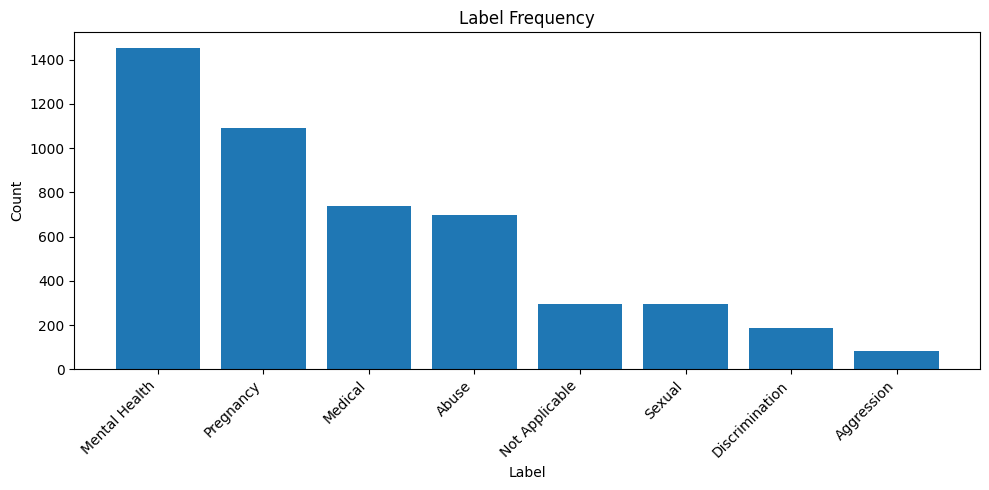

In [18]:
# === Cell 7: Bar chart for label frequencies ===
# What & why:
# - Visualizes how common each label is (sorted desc)
# - Helps you spot dominant or rare labels at a glance

import matplotlib.pyplot as plt

# If running in a fresh session (no memory), uncomment:
# import pandas as pd
# label_freq = pd.read_csv("./analysis_outputs/label_frequency.csv")

# Sort (should already be sorted, but just to be safe)
label_freq_plot = label_freq.sort_values("count", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.bar(label_freq_plot["label"], label_freq_plot["count"])
plt.title("Label Frequency")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

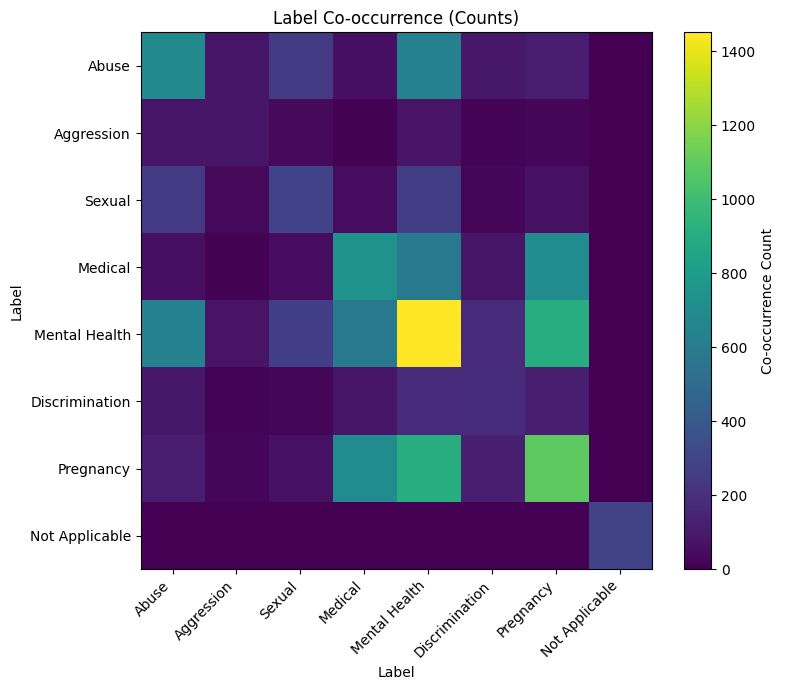

In [19]:
# === Cell 8: Co-occurrence heatmap ===
# What & why:
# - Shows which labels tend to appear together
# - Diagonal = individual label counts (handy as reference)
# - Off-diagonals = pair-wise co-occurrence counts

import numpy as np
import matplotlib.pyplot as plt

# If running in a fresh session (no memory), uncomment:
# import pandas as pd
# coocc_matrix = pd.read_csv("./analysis_outputs/label_cooccurrence_matrix.csv", index_col=0)

labels = list(coocc_matrix.index)
data = coocc_matrix.values.astype(float)

plt.figure(figsize=(8, 7))
im = plt.imshow(data, aspect="auto")  # default colormap
plt.title("Label Co-occurrence (Counts)")
plt.xlabel("Label")
plt.ylabel("Label")
plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(labels)), labels=labels)

# Add a simple colorbar
cbar = plt.colorbar(im)
cbar.set_label("Co-occurrence Count")

plt.tight_layout()
plt.show()


/home/ubuntu/.local/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/ubuntu/.local/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=Tru

<Figure size 1000x600 with 0 Axes>

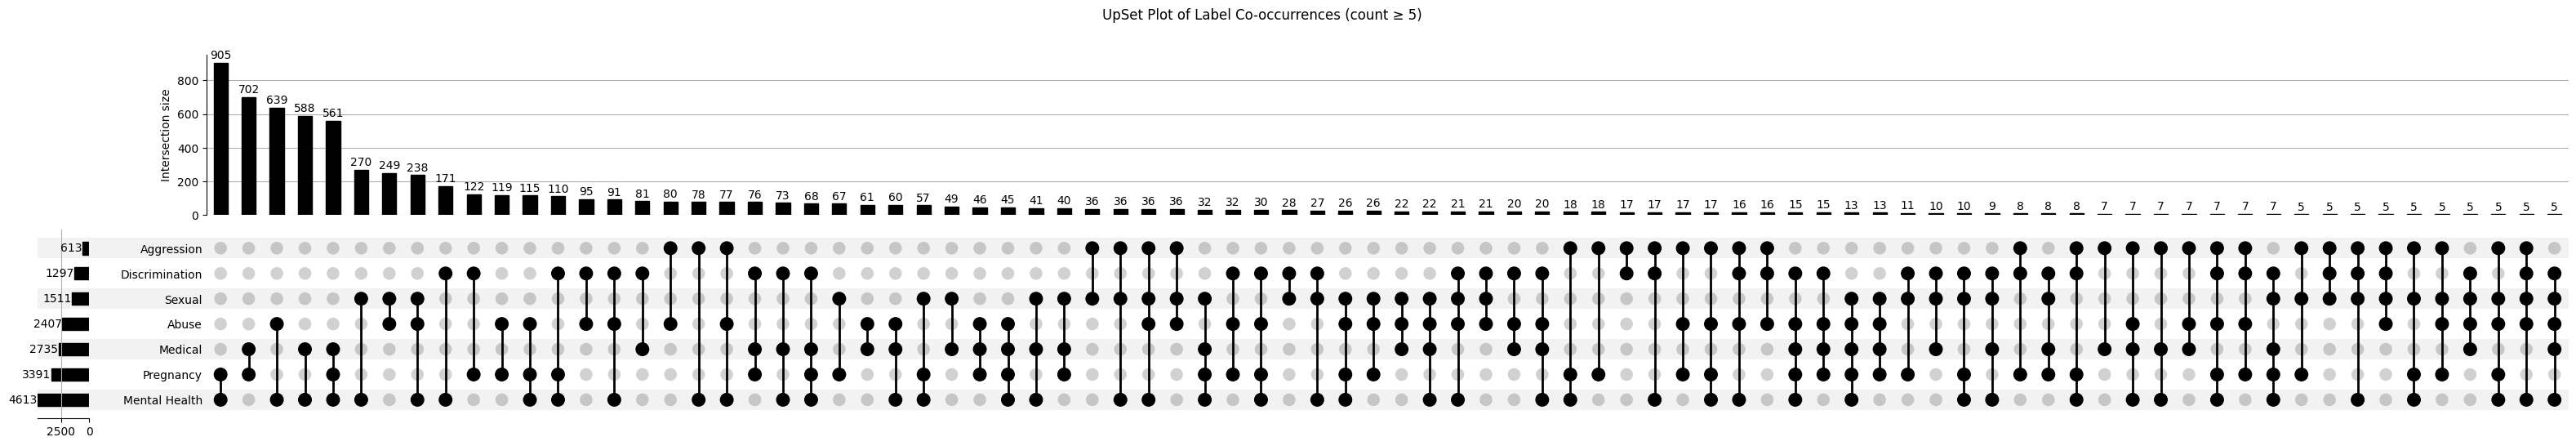

In [21]:
# === Cell 9: UpSet plot of frequent itemsets ===
# Shows intersections (any size) as bars; great for seeing which label combos are most common.

# !pip install upsetplot  # run once if needed

import pandas as pd
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

# Choose a threshold so we don’t overwhelm the plot
MIN_COUNT_FOR_UPSET = 5  # tweak per your dataset size
subset = coocc_all_sizes_df[coocc_all_sizes_df["count"] >= MIN_COUNT_FOR_UPSET].copy()

if subset.empty:
    print("No itemsets meet the MIN_COUNT_FOR_UPSET threshold.")
else:
    # Convert tuples to list of strings for from_memberships
    memberships = subset["itemset"].apply(lambda t: list(t))
    data = from_memberships(memberships, data=subset["count"])

    plt.figure(figsize=(10, 6))
    UpSet(data, show_counts=True, sort_by='cardinality').plot()
    plt.suptitle("UpSet Plot of Label Co-occurrences (count ≥ {})".format(MIN_COUNT_FOR_UPSET))
    plt.show()

# Topic Modelling

In [9]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import pandas as pd
from pathlib import Path

In [20]:
TP_OUTPUT_DIR = Path("/home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs")
TP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Paths set.")

✅ Paths set.


In [21]:
TEXT_COL = "text"

# Drop empty posts
df = df[df[TEXT_COL].notna() & (df[TEXT_COL].str.strip() != "")]
print("After dropping empty:", df.shape)

# Peek
display(df[[TEXT_COL, "labels_list"]].head(3))

After dropping empty: (2000, 18)


,text,labels_list
0,"Complications after abortion? Hi everyone, Ive...","[Medical, Pregnancy, Mental Health]"
1,Second MA abortion today and I'm absolutely te...,"[Medical, Pregnancy, Mental Health]"
2,Help needed/ live in Texas where abortion in b...,[Medical]


In [25]:
# === Required imports for custom UMAP + HDBSCAN models ===
import umap
import hdbscan
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

In [29]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")  
# 2️⃣ Dimensionality reduction (UMAP)
umap_model = umap.UMAP(
    n_neighbors=15,         # local vs. global structure (10–50)
    n_components=5,         # dimensionality of the embedding space (default=5)
    min_dist=0.0,           # how tightly UMAP packs points (0.0 = dense)
    metric='cosine',        # cosine is best for sentence embeddings
    random_state=42
)

# 3️⃣ Clustering model (HDBSCAN)
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=15,    # same as min_topic_size for consistency
    metric='euclidean',     # metric used after UMAP
    cluster_selection_method='eom', 
    prediction_data=True
)

# 4️⃣ Create BERTopic model
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,               # plug in custom UMAP
    hdbscan_model=hdbscan_model,         # plug in custom HDBSCAN
    min_topic_size=15,                   # small enough to catch niche themes
    n_gram_range=(1, 2),                 # include bigrams
    top_n_words=10,                      # number of words per topic to show
    calculate_probabilities=True,        # enables topic probability output
    verbose=True,
    language="english",
    nr_topics='auto'
)

In [37]:
# texts = df[TEXT_COL].tolist()
# topics, probs = topic_model.fit_transform(texts)

# # Save results to df
# df["topic_id"] = topics
# df["topic_probability"] = probs

# # Summary of discovered topics
# topic_info = topic_model.get_topic_info()
# display(topic_info.head(10))
# print(f"Total unique topics (excluding -1 outliers): {(topic_info.Topic != -1).sum()}")

In [34]:
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4,-1_my_and_dad_to,"[my, and, dad, to, my dad, that, he, the, it, ...",[I've been LC with my (29F) dad (54M) for quit...
1,0,1252,0_and_to_the_my,"[and, to, the, my, it, was, of, that, for, in]",[Being a parent has made me absolutely hate my...
2,1,744,1_and_to_the_me,"[and, to, the, me, my, he, was, it, that, of]",[I’ve been sexually assaulted and harassed sev...


In [38]:
import numpy as np, json

MODEL_DIR        = TP_OUTPUT_DIR / "bertopic_model"
DOC_TOPICS_PATH  = TP_OUTPUT_DIR / "document_topics.csv"
TOPIC_INFO_PATH  = TP_OUTPUT_DIR / "topic_summary.csv"
PROB_NPY_PATH    = TP_OUTPUT_DIR / "document_topic_probas.npy"

# 1) Fit model (heavy step)
texts = df[TEXT_COL].astype(str).tolist()
topics, probs = topic_model.fit_transform(texts)   # make sure topic_model was created with calculate_probabilities=True

# 2) Put assignments into df (avoid 2D assignment bug)
df["topic_id"] = topics

probs = np.asarray(probs)          # shape: (N_docs, N_topics)
df["topic_prob_max"] = probs.max(axis=1)  # 1-D, safe

# Top-K topic ids/probs (always create top1..top3; fill NaN if fewer topics exist)
K = min(3, probs.shape[1])
topk_idx = np.argsort(-probs, axis=1)[:, :K]             # indices of top-K topics
topk_val = np.take_along_axis(probs, topk_idx, axis=1)   # their probabilities

df["top1_topic_id"]   = topk_idx[:, 0] if K >= 1 else np.nan
df["top1_topic_prob"] = topk_val[:, 0] if K >= 1 else np.nan
df["top2_topic_id"]   = topk_idx[:, 1] if K >= 2 else np.nan
df["top2_topic_prob"] = topk_val[:, 1] if K >= 2 else np.nan
df["top3_topic_id"]   = topk_idx[:, 2] if K >= 3 else np.nan
df["top3_topic_prob"] = topk_val[:, 2] if K >= 3 else np.nan

# Optional: store full probability vector sparsely as JSON (keeps all info in one column)
def sparse_json(row):
    nz = np.nonzero(row)[0]
    return json.dumps({int(i): float(row[i]) for i in nz})
df["topic_probs_json"] = [sparse_json(row) for row in probs]

# 3) Topic summary table
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))
print(f"Total unique topics (excluding -1 outliers): {(topic_info.Topic != -1).sum()}")

# 4) SAVE model + outputs immediately (so accidental reruns don’t matter)
topic_model.save(MODEL_DIR)
topic_info.to_csv(TOPIC_INFO_PATH, index=False)

export_cols = ["text","labels_list","topic_id","topic_prob_max",
               "top1_topic_id","top1_topic_prob",
               "top2_topic_id","top2_topic_prob",
               "top3_topic_id","top3_topic_prob",
               "topic_probs_json"]
existing_cols = [c for c in export_cols if c in df.columns]
df[existing_cols].to_csv(DOC_TOPICS_PATH, index=False)

np.save(PROB_NPY_PATH, probs)

print("\n✅ Saved:")
print(" - Model:", MODEL_DIR.resolve())
print(" - Topic summary:", TOPIC_INFO_PATH.resolve())
print(" - Document topics:", DOC_TOPICS_PATH.resolve())
print(" - Full prob matrix (.npy):", PROB_NPY_PATH.resolve())

2025-10-16 19:46:41,911 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2025-10-16 19:58:21,804 - BERTopic - Embedding - Completed ✓
2025-10-16 19:58:21,805 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-16 19:58:31,839 - BERTopic - Dimensionality - Completed ✓
2025-10-16 19:58:31,840 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-16 19:58:31,984 - BERTopic - Cluster - Completed ✓
2025-10-16 19:58:31,985 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-10-16 19:58:33,951 - BERTopic - Representation - Completed ✓
2025-10-16 19:58:33,957 - BERTopic - Topic reduction - Reducing number of topics
2025-10-16 19:58:33,972 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-16 19:58:36,467 - BERTopic - Representation - Completed ✓
2025-10-16 19:58:36,474 - BERTopic - Topic reduction - Reduced number of topics from 3 to 3


,Topic,Count,Name,Representation,Representative_Docs
0,-1,4,-1_my_and_dad_to,"[my, and, dad, to, my dad, that, he, the, it, ...",[I've been LC with my (29F) dad (54M) for quit...
1,0,1252,0_and_to_the_my,"[and, to, the, my, it, was, of, that, for, in]",[Being a parent has made me absolutely hate my...
2,1,744,1_and_to_the_me,"[and, to, the, me, my, he, was, it, that, of]",[I’ve been sexually assaulted and harassed sev...


2025-10-16 19:58:37,039 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Total unique topics (excluding -1 outliers): 2

✅ Saved:
 - Model: /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/bertopic_model
 - Topic summary: /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/topic_summary.csv
 - Document topics: /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/document_topics.csv
 - Full prob matrix (.npy): /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/document_topic_probas.npy


In [39]:
BASE = Path("/home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs")
df_doc = pd.read_csv(BASE/"document_topics.csv")
out_pct = (df_doc["topic_id"] == -1).mean()*100
print(f"Outliers (topic = -1): {out_pct:.1f}%   ({(df_doc['topic_id']==-1).sum()} of {len(df_doc)})")

Outliers (topic = -1): 0.2%   (4 of 2000)


In [44]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=0.003,     # keep tokens that appear in ≥0.3% of docs
    max_df=0.80,      # drop tokens in >80% of docs
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

texts = df["text"].astype(str).tolist()

# Re-extract topic words with the improved vectorizer
topic_model.update_topics(texts, vectorizer_model=vectorizer_model, n_gram_range=(1,2))
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4,-1_lc_dad wants_mom passed_dad mom,"[lc, dad wants, mom passed, dad mom, wants hob...",[I've been LC with my (29F) dad (54M) for quit...
1,0,1252,0_weeks_abortion_pregnancy_miscarriage,"[weeks, abortion, pregnancy, miscarriage, days...",[Being a parent has made me absolutely hate my...
2,1,744,1_said_sexual_remember_say,"[said, sexual, remember, say, sex, guy, school...",[I’ve been sexually assaulted and harassed sev...


In [45]:
def topic_name(tm, t, topn=4):
    if t == -1: return "Outliers"
    words = [w for w,_ in tm.get_topic(t)[:topn]]
    return " / ".join(words)

topic_info["topic_name"] = topic_info["Topic"].apply(lambda t: topic_name(topic_model, t, 4))
topic_info = topic_info.rename(columns={"Count":"doc_count"})
display(topic_info[["Topic","topic_name","doc_count"]].head(15))

,Topic,topic_name,doc_count
0,-1,Outliers,4
1,0,weeks / abortion / pregnancy / miscarriage,1252
2,1,said / sexual / remember / say,744


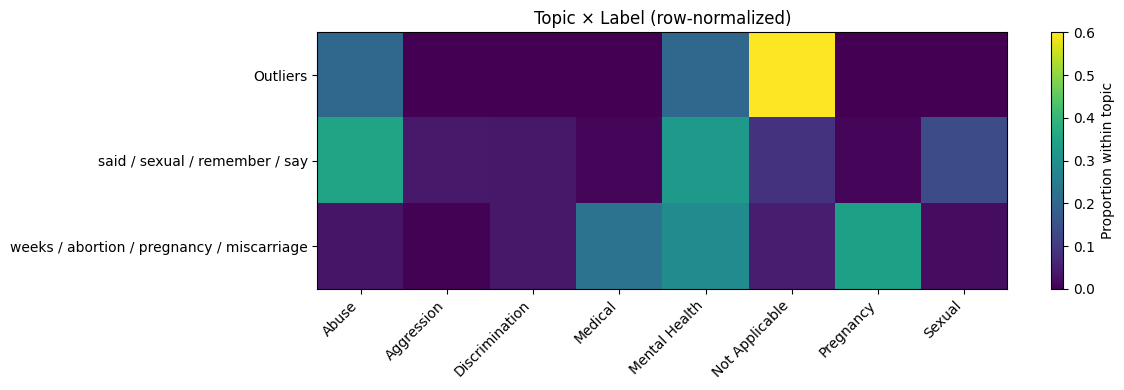

In [46]:
if isinstance(df_doc["labels_list"].iloc[0], str):
    df_doc["labels_list"] = df_doc["labels_list"].apply(eval)

# explode to one row per (doc, label)
exploded = df_doc.explode("labels_list")
exploded = exploded.rename(columns={"labels_list":"label"})

# counts per (topic, label)
ct = (exploded.groupby(["topic_id","label"]).size()
      .rename("count").reset_index())

# add topic names
name_map = dict(zip(topic_info["Topic"], topic_info["topic_name"]))
ct["topic_name"] = ct["topic_id"].map(name_map)

# make a pivot table for heatmap
pivot = ct.pivot_table(index="topic_name", columns="label", values="count", fill_value=0)
# normalize rows to proportions (optional; comment out if you want raw counts)
pivot_prop = pivot.div(pivot.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

plt.figure(figsize=(12, max(4, 0.5*len(pivot_prop))))
im = plt.imshow(pivot_prop.values, aspect="auto")
plt.yticks(range(len(pivot_prop.index)), pivot_prop.index)
plt.xticks(range(len(pivot_prop.columns)), pivot_prop.columns, rotation=45, ha="right")
plt.colorbar(im, label="Proportion within topic")
plt.title("Topic × Label (row-normalized)")
plt.tight_layout()
plt.show()

(Interactive viz may require notebook extension) -> zero-size array to reduction operation maximum which has no identity


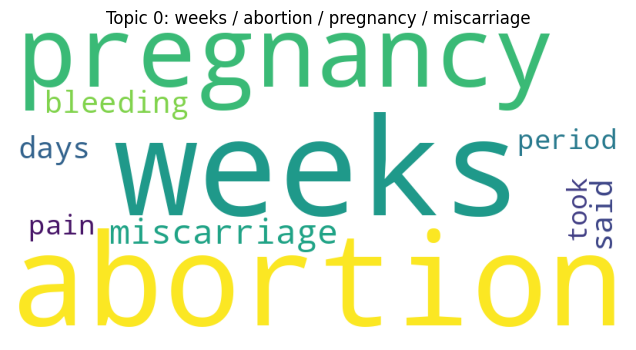

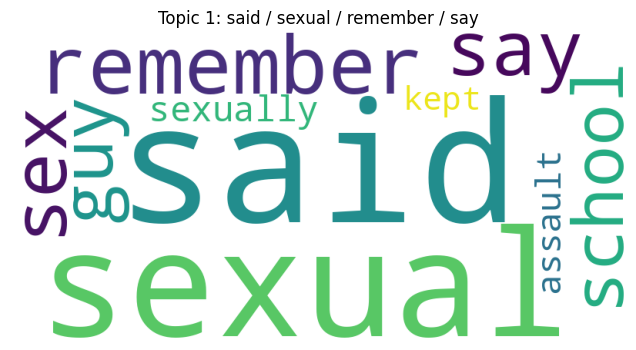

In [48]:
# Interactive (if running in Jupyter with JS enabled)
try:
    topic_model.visualize_barchart(top_n_topics=10).show()
    topic_model.visualize_topics().show()
except Exception as e:
    print("(Interactive viz may require notebook extension) ->", e)

# Word clouds from topic word weights (static)
from wordcloud import WordCloud
for t in topic_info["Topic"].head(6):
    if t == -1: continue
    freqs = {w: float(s) for w, s in topic_model.get_topic(t)}
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freqs)
    plt.figure(figsize=(8,4)); plt.imshow(wc); plt.axis("off"); plt.title(f"Topic {t}: {name_map.get(t,'')}")
    plt.show()

In [49]:
from pathlib import Path

BASE = Path("/home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs")
MODEL_DIR2 = BASE / "bertopic_model_clean"    # new folder so original stays intact
TOPIC_INFO_CLEAN = BASE / "topic_summary_clean.csv"
DOC_TOPICS_CLEAN = BASE / "document_topics_clean.csv"

# Update df_doc topic ids if you changed them (reduce_outliers/reduce_topics)
# If you ran Step 3 with new_topics, persist them:
if 'new_topics' in locals():
    df_doc["topic_id"] = new_topics

# Recompute top1 topic after merges (optional but recommended)
# (You can skip if you don't need these columns here.)
# Note: If you want exact new probabilities, you'd call transform() to get new probs.

MODEL_DIR2.parent.mkdir(parents=True, exist_ok=True)
topic_model.save(MODEL_DIR2)
topic_info.to_csv(TOPIC_INFO_CLEAN, index=False)
df_doc.to_csv(DOC_TOPICS_CLEAN, index=False)

print("✅ Saved updated assets:")
print(" -", MODEL_DIR2.resolve())
print(" -", TOPIC_INFO_CLEAN.resolve())
print(" -", DOC_TOPICS_CLEAN.resolve())

2025-10-16 20:27:29,759 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


✅ Saved updated assets:
 - /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/bertopic_model_clean
 - /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/topic_summary_clean.csv
 - /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/document_topics_clean.csv


In [50]:
from collections import Counter
import numpy as np

def umass_coherence_for_topic(words, corpus_tokens, eps=1e-12):
    D = len(corpus_tokens)
    dfc = Counter()
    pc = Counter()
    for toks in corpus_tokens:
        uniq = set(toks)
        for w in uniq:
            dfc[w]+=1
        for i in range(1, len(words)):
            for j in range(i):
                if words[i] in uniq and words[j] in uniq:
                    pc[(words[i], words[j])] += 1
    score = 0.0; pairs=0
    for i in range(1, len(words)):
        for j in range(i):
            cw = pc[(words[i], words[j])]
            dw = dfc[words[j]]
            score += np.log((cw + eps) / (dw if dw>0 else 1))
            pairs += 1
    return score / max(pairs,1)

# lightweight tokenization
corpus_tokens = df["text"].str.lower().str.replace(r"[^a-z\s]", " ", regex=True).str.split()
coh = []
for t in topic_info.Topic[topic_info.Topic!=-1][:10]:
    words = [w for w,_ in topic_model.get_topic(t)[:10]]
    coh.append((t, umass_coherence_for_topic(words, corpus_tokens)))
print("UMass coherence (first 10 topics):")
for t, c in coh:
    print(f"Topic {t}: {c:.3f}")

UMass coherence (first 10 topics):
Topic 0: -1.308
Topic 1: -1.470


In [52]:
# explode labels and compute counts per (topic, label)
df_doc = pd.read_csv(BASE / "document_topics_clean.csv")
df_doc["labels_list"] = df_doc["labels_list"].apply(eval) if isinstance(df_doc["labels_list"].iloc[0], str) else df_doc["labels_list"]
df_ex = df_doc.explode("labels_list")

topic_label_counts = (df_ex.groupby(["topic_id","labels_list"])
                         .size().reset_index(name="count"))

# Normalize per-topic to proportions
topic_totals = topic_label_counts.groupby("topic_id")["count"].sum().rename("topic_total")
topic_label_props = topic_label_counts.merge(topic_totals, on="topic_id")
topic_label_props["prop"] = topic_label_props["count"] / topic_label_props["topic_total"]

topic_label_props.sort_values(["topic_id","prop"], ascending=[True,False]).head(20)

,topic_id,labels_list,count,topic_total,prop
2,-1,Not Applicable,3,5,0.600000
0,-1,Abuse,1,5,0.200000
1,-1,Mental Health,1,5,0.200000
9,0,Pregnancy,1076,3163,0.340183
7,0,Mental Health,912,3163,0.288334
6,0,Medical,721,3163,0.227948
8,0,Not Applicable,146,3163,0.046159
5,0,Discrimination,121,3163,0.038255
3,0,Abuse,111,3163,0.035093
10,0,Sexual,62,3163,0.019602


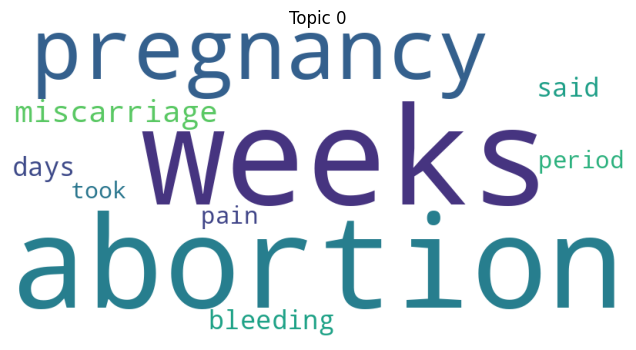

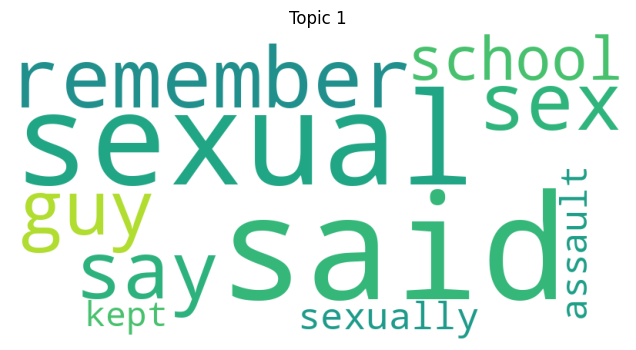

In [53]:
# !pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for t in topic_info.Topic[topic_info.Topic!=-1].head(6):
    words = topic_model.get_topic(t)  # list of (word, weight)
    freqs = {w: float(s) for w,s in words}
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freqs)
    plt.figure(figsize=(8,4)); plt.imshow(wc); plt.axis("off"); plt.title(f"Topic {t}")
    plt.show()